<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>ML/DL</b></center>

<center><b><h1> </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.preprocessing import StandardScaler


ModuleNotFoundError: No module named 'sklearn_extra'

In [45]:
%pip install scikit-learn-extra


  Using cached scikit-learn-extra-0.3.0.tar.gz (818 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build scikit-learn-extra
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Building wheel for scikit-learn-extra (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [77 lines of output]
      C:\Users\HP\AppData\Local\Temp\pip-build-env-2tz5f37d\overlay\Lib\site-packages\setuptools\dist.py:599: SetuptoolsDeprecationWarning: Invalid dash-separated key 'description-file' in 'metadata' (setup.cfg), please use the underscore name 'description_file' instead.
      !!
      
              ********************************************************************************
              Usage of dash-separated 'description-file' will not be supported in future
              versions. Please use the underscore name 'description_file' instead.
              (Affected: scikit-learn-extra).
      
              Available configuration options are listed in:
              https://setuptools.pypa.io/en/latest/userguide/declarative_config.html
      
              This deprecation is overdue, please update your project

# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [2]:
df=pd.read_csv("StudentsPerformance.csv")

# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [4]:
print(df.info())
print(df.isnull().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# Step 4: Display PairPlot

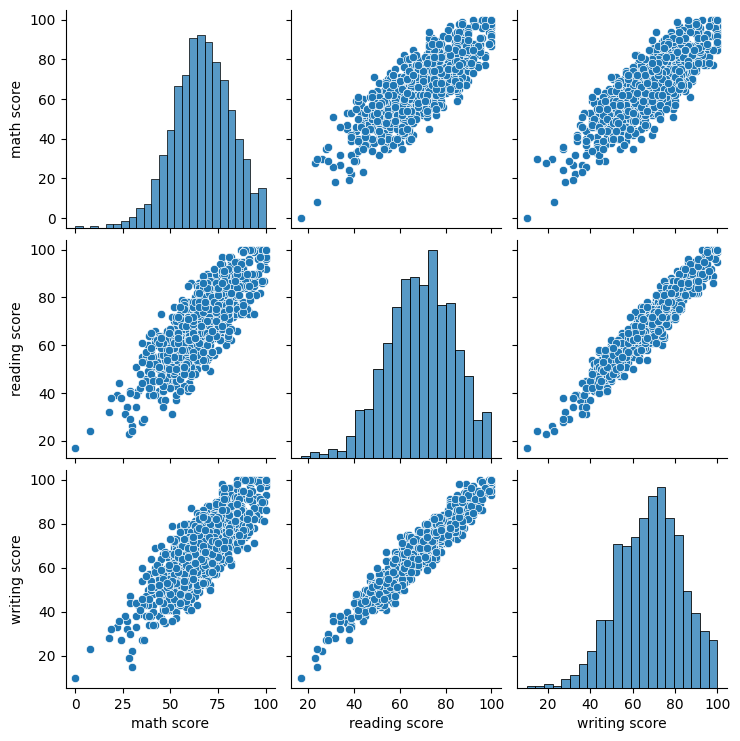

In [ ]:
sns.pairplot(df[X_scale])
plt.show()

# Step 5: Correlation heatmap

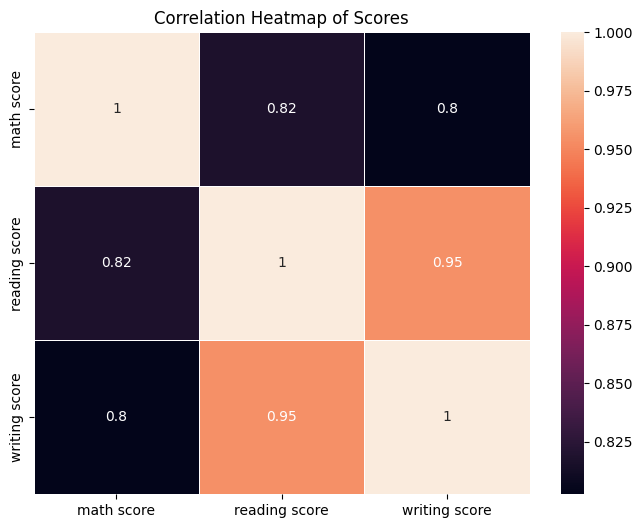

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[X_scale].corr(), annot=True, linewidths=0.5)
plt.title('Correlation Heatmap of Scores')
plt.show()

# Step 6: Distribution of numerical features

In [ ]:
X_scale = ['math score', 'reading score', 'writing score']

# Step 7: Apply StandardScaler

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[X_scale])

# Step 8: Elbow method to find optimal k

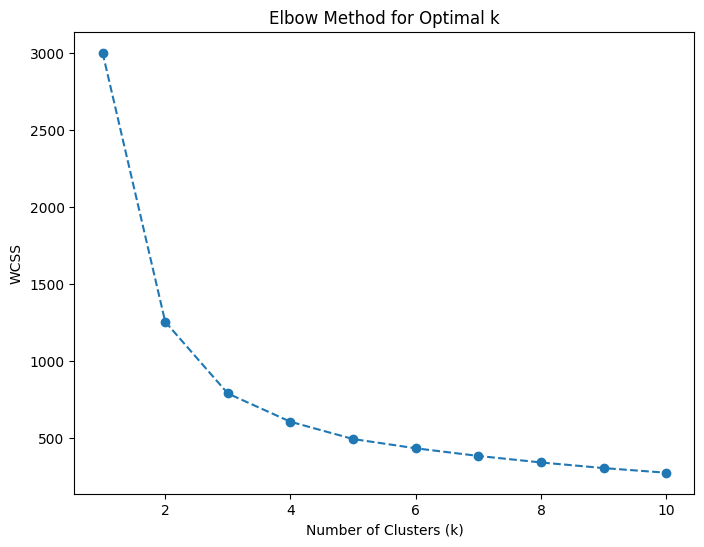

In [17]:
wcss=[]
k_range=range(1,11)

for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(k_range,wcss,marker='o',linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [19]:
optimal_k=3
kmeans=KMeans(n_clusters=optimal_k,random_state=42,n_init=10)
y_kmeans=kmeans.fit_predict(X_scaled)
df['Cluster']=y_kmeans


# Step 10: Print Cluster Center

In [22]:
print("Cluster Centers (scaled):", kmeans.cluster_centers_)

print("\nCluster Centers (original scale):", scaler.inverse_transform(kmeans.cluster_centers_))

Cluster Centers (scaled): [[-0.04951336 -0.04870596 -0.01529686]
 [-1.18720058 -1.26762535 -1.28838441]
 [ 1.03099793  1.09485536  1.06358515]]

Cluster Centers (original scale): [[65.33860045 68.45823928 67.82167043]
 [48.09638554 50.67068273 48.48594378]
 [81.71428571 85.1461039  84.20779221]]


# Step 11: Plot Cluster

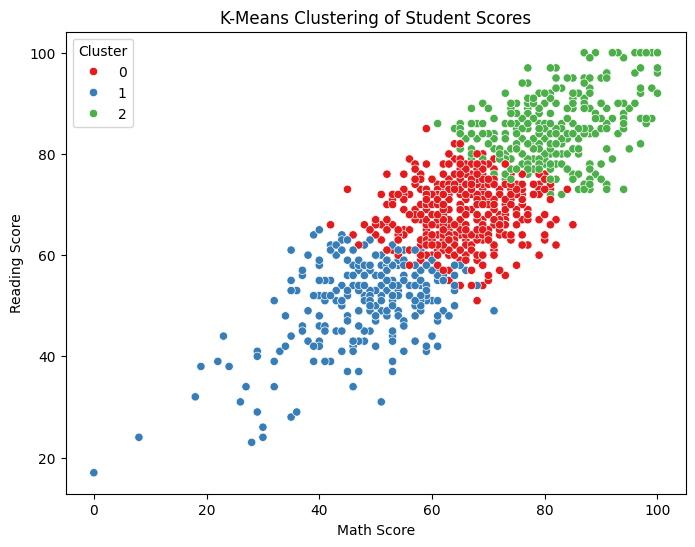

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='math score', y='reading score', hue='Cluster', data=df, palette='Set1')
plt.title('K-Means Clustering of Student Scores')
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.legend(title='Cluster')
plt.show()

# Step 12:Analyze clusters 

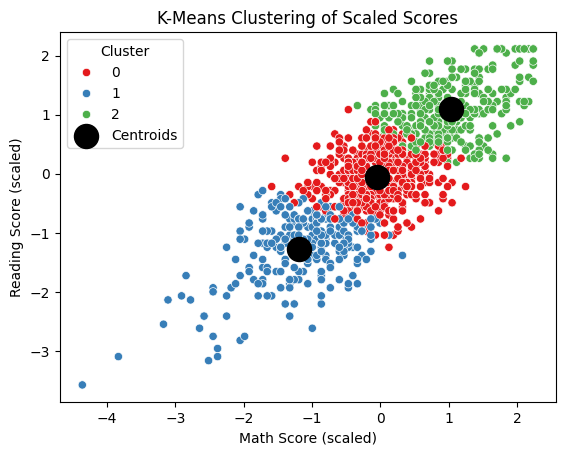

In [29]:
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=y_kmeans, data=df, palette='Set1')

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=300, c='black', marker='o', label='Centroids')
plt.title('K-Means Clustering of Scaled Scores')
plt.xlabel('Math Score (scaled)')
plt.ylabel('Reading Score (scaled)') 
plt.legend(title='Cluster')
plt.show()

In [52]:
groupby_parental_education = df.groupby('parental level of education')['Cluster'].value_counts().unstack().fillna(0)
groupby_parental_education[1]

parental level of education
associate's degree    53
bachelor's degree     19
high school           69
master's degree        8
some college          43
some high school      57
Name: 1, dtype: int64

# Step 13: Perform K-Medoids

In [47]:
kmedoids=kmedoids(n_clusters=3,random_state=42,method='pam')
y_mediods=kmedoids.fit_predict(X_scaled)
df['Medoid_Cluster']=y_mediods

NameError: name 'kmedoids' is not defined

# Step:14 Comparison of K-means and K-medoids Clusters

# Step: 15 | USE KMEAN++
